In [2]:
!pip install -q -U huggingface_hub
!pip install -q -U transformers peft bitsandbytes accelerate librosa scipy scikit-learn seaborn
!git clone "https://github.com/NitinKumar314/AVANURMI" 2>/dev/null || echo "Repo cloned ✓"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 11.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 78.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 60.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.1 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.


In [5]:
import gc, os, json, random
import numpy as np
import torch
import torch.nn as nn
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [6]:
LABELS = ["AZU", "BRE", "KIK", "MLE", "MLO", "MMA", "MME", "MXE"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
print(f"Classes: {LABELS}")

Classes: ['AZU', 'BRE', 'KIK', 'MLE', 'MLO', 'MMA', 'MME', 'MXE']


In [ ]:
from huggingface_hub import login
login(token="not here")  

tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b-it")
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2b-it",
    quantization_config=bnb_config,
    device_map={"":0},
)

base_model = prepare_model_for_kbit_training(base_model)
base_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

base_model = get_peft_model(base_model, lora_config)
base_model.print_trainable_parameters()
print(f"VRAM after load: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

trainable params: 1,843,200 || all params: 2,508,015,616 || trainable%: 0.0735
VRAM after load: 3.13 GB


In [8]:
def extract_symbolic_features(signal, sr=22050):
    from scipy.signal import find_peaks

    fft = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), d=1/sr)
    mask = (freqs > 500) & (freqs < 11000)
    fft_m, freqs_m = fft[mask], freqs[mask]
    dom_freq_hz = freqs_m[np.argmax(fft_m)]

    bw_hz = float(np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr)))
    if bw_hz < 1200:   bw_cat = "Low"
    elif bw_hz < 1580: bw_cat = "Medium"
    else:              bw_cat = "High"

    stft = np.abs(librosa.stft(signal, n_fft=2048))
    stft_std = float(np.std(stft))
    if stft_std < 12.7:   hs_cat = "High"
    elif stft_std < 14.0: hs_cat = "Medium"
    else:                 hs_cat = "Low"

    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_en = np.sum(np.maximum(mel, 0), axis=1)
    mel_freqs = librosa.mel_frequencies(n_mels=128, fmin=0, fmax=sr/2)
    mel_wmean = float(np.average(mel_freqs, weights=mel_en + 1e-9))
    if mel_wmean < 500:    mer_cat = "Lower"
    elif mel_wmean < 2000: mer_cat = "Middle"
    else:                  mer_cat = "Upper"

    peaks, _ = find_peaks(fft_m, height=np.mean(fft_m)+np.std(fft_m), distance=50)
    n_peaks = len(peaks)
    if n_peaks < 116:   vt_cat = "Low"
    elif n_peaks < 187: vt_cat = "Medium"
    else:               vt_cat = "High"

    rms_val = float(np.sqrt(np.mean(fft_m**2)))
    if rms_val < 3.69:   rms_cat = "Low"
    elif rms_val < 8.12: rms_cat = "Medium"
    else:                rms_cat = "High"

    centered = fft_m - np.mean(fft_m)
    zcr = float(np.sum(np.abs(np.diff(np.sign(centered)))) / (2*len(centered)))
    if zcr < 0.0948:   zcr_cat = "Low"
    elif zcr < 0.1345: zcr_cat = "Medium"
    else:              zcr_cat = "High"

    centroid_khz = round(float(np.mean(
        librosa.feature.spectral_centroid(y=signal, sr=sr)))/1000, 2)

    hop = 512
    rms_env = librosa.feature.rms(y=signal, hop_length=hop)[0]
    rms_smooth = np.convolve(rms_env, np.ones(5)/5, mode='same')
    env_peaks, _ = find_peaks(rms_smooth,
        height=np.mean(rms_smooth)+0.3*np.std(rms_smooth),
        distance=int(sr*0.05/hop))
    pulse_rate = round(len(env_peaks)/(len(signal)/sr), 1)

    rolloff_khz = round(float(np.mean(
        librosa.feature.spectral_rolloff(y=signal, sr=sr, roll_percent=0.85)))/1000, 2)

    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std  = np.std(mfccs, axis=1)
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta_mean = np.mean(mfcc_delta, axis=1)

    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)

    features = {
        "DominantFreqBand":     f"{dom_freq_hz/1000:.2f}kHz",
        "SpectralBandwidth":    bw_cat,
        "HarmonicStability":    hs_cat,
        "MelEnergyRegion":      mer_cat,
        "VerticalTransients":   vt_cat,
        "RMSLevel":             rms_cat,
        "ZCRLevel":             zcr_cat,
        "SpectralCentroid_kHz": centroid_khz,
        "PulseRate":            pulse_rate,
        "SpectralRolloff_kHz":  rolloff_khz,
        "ChromaMean":           round(float(np.mean(chroma)), 4),
        "ChromaStd":            round(float(np.std(chroma)), 4),
        "SpectralContrast":     round(float(np.mean(contrast)), 4),
    }

    for i in range(13):
        features[f"MFCC{i+1}_mean"]  = round(float(mfcc_mean[i]), 4)
        features[f"MFCC{i+1}_std"]   = round(float(mfcc_std[i]), 4)
        features[f"MFCC{i+1}_delta"] = round(float(mfcc_delta_mean[i]), 4)

    return features

print("extract_symbolic_features() ready ✓")

extract_symbolic_features() ready ✓


In [9]:
def augment_audio(signal, sr):
    augmented = []
    try: augmented.append(librosa.effects.time_stretch(signal, rate=0.85))
    except: pass
    try: augmented.append(librosa.effects.time_stretch(signal, rate=1.15))
    except: pass
    try: augmented.append(librosa.effects.pitch_shift(signal, sr=sr, n_steps=2))
    except: pass
    try: augmented.append(librosa.effects.pitch_shift(signal, sr=sr, n_steps=-2))
    except: pass
    noise = np.random.normal(0, 0.003*np.std(signal), len(signal))
    augmented.append(signal + noise)
    noise2 = np.random.normal(0, 0.008*np.std(signal), len(signal))
    augmented.append(signal + noise2)
    return augmented

all_species_paths = {
    "AZU": ["/kaggle/working/AVANURMI/Azanicadazuluensis/",
            "/kaggle/working/AVANURMI/Avanurmi2/Azanicadazuluensis/"],
    "BRE": ["/kaggle/working/AVANURMI/Brevisianabrevis/",
            "/kaggle/working/AVANURMI/Avanurmi2/Brevisianabrevis/"],
    "KIK": ["/kaggle/working/AVANURMI/Kikihiamuta/",
            "/kaggle/working/AVANURMI/Avanurmi2/Kikihiamuta/"],
    "MLE": ["/kaggle/working/AVANURMI/Myopsaltaleona/",
            "/kaggle/working/AVANURMI/Avanurmi2/Myopsaltaleona/"],
    "MLO": ["/kaggle/working/AVANURMI/Myopsaltalongicauda/",
            "/kaggle/working/AVANURMI/Avanurmi2/Myopsaltalongicauda/"],
    "MMA": ["/kaggle/working/AVANURMI/Myopsaltamackinlayi/",
            "/kaggle/working/AVANURMI/Avanurmi2/Myopsaltamackinlayi/"],
    "MME": ["/kaggle/working/AVANURMI/Myopsaltamelanobasis/",
            "/kaggle/working/AVANURMI/Avanurmi2/Myopsaltamelanobasis/"],
    "MXE": ["/kaggle/working/AVANURMI/Myopsaltaxerograsidia/",
            "/kaggle/working/AVANURMI/Avanurmi2/Myopsaltaxerograsidia/"],
}

train_data = []

for label, paths in all_species_paths.items():
    seen = set()
    for folder in paths:
        if not os.path.exists(folder):
            continue
        for fname in sorted(os.listdir(folder)):
            if not fname.endswith(".wav") or fname in seen:
                continue
            seen.add(fname)
            try:
                audio, sr = librosa.load(os.path.join(folder, fname), sr=22050)
                feats = extract_symbolic_features(audio, sr)
                train_data.append({"features": feats, "label": label, "augmented": False})
                for aug in augment_audio(audio, sr):
                    try:
                        feats_aug = extract_symbolic_features(aug, sr)
                        train_data.append({"features": feats_aug, "label": label, "augmented": True})
                    except: pass
            except Exception as e:
                print(f"ERROR {label}/{fname}: {e}")

# Save immediately
os.makedirs("/kaggle/working", exist_ok=True)
with open("/kaggle/working/train_data.json", "w") as f:
    json.dump(train_data, f)

print(f"\n✓ Total samples: {len(train_data)}")
print(f"  Original: {sum(1 for s in train_data if not s['augmented'])}")
print(f"  Augmented: {sum(1 for s in train_data if s['augmented'])}")
for label in LABELS:
    n = sum(1 for s in train_data if s['label'] == label)
    print(f"  {label}: {n}")

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(



✓ Total samples: 308
  Original: 44
  Augmented: 264
  AZU: 28
  BRE: 35
  KIK: 42
  MLE: 49
  MLO: 28
  MMA: 49
  MME: 35
  MXE: 42


In [10]:
CAT_MAP = {"Low":0, "Medium":1, "High":2, "Lower":0, "Middle":1, "Upper":2}

top_features = [
    "MFCC2_mean", "MFCC5_mean", "SpectralContrast", "ChromaStd",
    "MFCC3_mean", "MFCC1_std", "MFCC9_mean", "DominantFreqBand",
    "ChromaMean", "MFCC6_mean", "SpectralCentroid_kHz",
    "SpectralRolloff_kHz", "MFCC9_delta", "MFCC6_delta", "MFCC4_delta"
]

def featurize_top(sample):
    row = []
    for k in top_features:
        v = sample['features'][k]
        if isinstance(v, str):
            if v.endswith("kHz"):
                row.append(float(v.replace("kHz", "")))
            else:
                row.append(float(CAT_MAP.get(v, 0)))
        else:
            row.append(float(v))
    return row

X = np.array([featurize_top(s) for s in train_data])
y = np.array([LABEL2ID[s['label']] for s in train_data])

# Group IDs — originals and their augmentations stay together
group_id = 0
groups = []
for s in train_data:
    if not s['augmented']:
        current_group = group_id
        group_id += 1
    groups.append(current_group)
groups = np.array(groups)

rf = RandomForestClassifier(
    n_estimators=1000, max_depth=4,
    min_samples_leaf=2, random_state=42,
    class_weight='balanced'
)

gkf = GroupKFold(n_splits=5)
fold_scores = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    rf.fit(X[train_idx], y[train_idx])
    score = rf.score(X[val_idx], y[val_idx])
    fold_scores.append(score)
    print(f"Fold {fold+1}: {score:.3f}")

print(f"\nRF Group CV (honest): {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

Fold 1: 0.444
Fold 2: 0.603
Fold 3: 0.762
Fold 4: 0.571
Fold 5: 0.554

RF Group CV (honest): 0.587 ± 0.103


In [11]:
class GemmaClassifier(nn.Module):
    def __init__(self, base_model, num_labels=8, hidden_size=2048):
        super().__init__()
        self.base = base_model
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_labels)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        with torch.no_grad():
            outputs = self.base(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )
        hidden = outputs.hidden_states[-1][:, -1, :]
        logits = self.classifier(hidden)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(label_smoothing=0.1)(logits, labels)
        return (loss, logits) if loss is not None else logits

clf_model = GemmaClassifier(base_model, num_labels=len(LABELS)).to(device)
print(f"Head params: {sum(p.numel() for p in clf_model.classifier.parameters()):,}")
print("GemmaClassifier ready ✓")

Head params: 542,024
GemmaClassifier ready ✓


In [12]:
class EmbeddingDataset(torch.utils.data.Dataset):
    def __init__(self, samples):
        self.samples = samples

    def build_prompt(self, features):
        return (
            "You are an acoustic cicada species classifier.\n\n"
            "Key rules:\n"
            "- MelEnergyRegion=Lower → strongly suggests KIK\n"
            "- VerticalTransients=Low → strongly suggests AZU\n"
            "- PulseRate > 4.0 → strongly suggests MME\n"
            "- SpectralBandwidth=Medium → strongly suggests BRE\n\n"
            "Input acoustic features:\n"
            f"{json.dumps(features, indent=2)}\n\n"
            "Species label:"
        )

    def __getitem__(self, idx):
        sample = self.samples[idx]
        prompt = self.build_prompt(sample['features'])
        enc = tokenizer(prompt, return_tensors="pt",
                        truncation=True, max_length=512,
                        add_special_tokens=True)
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(LABEL2ID[sample['label']], dtype=torch.long),
        }

    def __len__(self):
        return len(self.samples)

def collate_fn(batch):
    return {
        "input_ids": pad_sequence([b["input_ids"] for b in batch],
                                   batch_first=True, padding_value=tokenizer.pad_token_id),
        "attention_mask": pad_sequence([b["attention_mask"] for b in batch],
                                        batch_first=True, padding_value=0),
        "labels": torch.stack([b["labels"] for b in batch]),
    }

print("EmbeddingDataset ready ✓")

EmbeddingDataset ready ✓


In [19]:
clf_model = GemmaClassifier(base_model, num_labels=len(LABELS)).to(device)

In [20]:
# Group-aware split
original_samples = [s for s in train_data if not s['augmented']]
random.seed(42)
test_originals, train_originals = [], []
for label in LABELS:
    label_samples = [s for s in original_samples if s['label'] == label]
    random.shuffle(label_samples)
    test_originals.append(label_samples[0])
    train_originals.extend(label_samples[1:])

train_data_clf = [s for s in train_data if s not in test_originals]
test_data_clf  = test_originals
print(f"Train: {len(train_data_clf)} | Test: {len(test_data_clf)}")

# DataLoader
class_counts = {l: sum(1 for s in train_data_clf if s['label']==l) for l in LABELS}
sample_weights = [1.0/class_counts[s['label']] for s in train_data_clf]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
clf_loader = DataLoader(EmbeddingDataset(train_data_clf),
                        batch_size=4, sampler=sampler, collate_fn=collate_fn)

# FIX 2 — Train BOTH head AND LoRA params
optimizer = torch.optim.AdamW([
    {"params": clf_model.classifier.parameters(), "lr": 1e-3},
    {"params": [p for p in clf_model.base.parameters() if p.requires_grad], "lr": 2e-5},
], weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

# FIX 1 — Use AVERAGE loss for early stopping
best_loss = float('inf')
patience, no_improve = 20, 0

for epoch in range(150):
    clf_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in clf_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["labels"].to(device)
        optimizer.zero_grad()
        loss, logits = clf_model(ids, mask, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf_model.classifier.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(-1) == lbls).sum().item()
        total += lbls.size(0)

    scheduler.step()
    avg_loss = total_loss / len(clf_loader)  # FIX — average not sum

    if avg_loss < best_loss:
        best_loss = avg_loss
        no_improve = 0
        torch.save(clf_model.classifier.state_dict(), "/kaggle/working/best_head.pt")
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"Early stop at epoch {epoch+1}")
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Avg Loss: {avg_loss:.4f} | Acc: {correct/total*100:.1f}%")

clf_model.classifier.load_state_dict(torch.load("/kaggle/working/best_head.pt"))
print("Best model restored ✓")

# Evaluate
clf_model.eval()
correct = 0
print("\n=== TEST RESULTS ===")
for s in test_data_clf:
    prompt = EmbeddingDataset([s]).build_prompt(s['features'])
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = clf_model(enc["input_ids"], enc["attention_mask"])
    pred = LABELS[logits.argmax(-1).item()]
    status = "✓" if pred == s['label'] else "✗"
    if pred == s['label']: correct += 1
    print(f"{status} True: {s['label']} | Predicted: {pred}")

print(f"\nGemma Test Accuracy: {correct}/{len(test_data_clf)} = {correct/len(test_data_clf)*100:.1f}%")
print(f"RF Baseline: 58.7%")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Train: 300 | Test: 8
Epoch  10 | Avg Loss: 1.8697 | Acc: 30.7%
Epoch  20 | Avg Loss: 1.6730 | Acc: 41.7%
Epoch  30 | Avg Loss: 1.6043 | Acc: 43.7%
Epoch  40 | Avg Loss: 1.4584 | Acc: 52.0%
Epoch  50 | Avg Loss: 1.4994 | Acc: 48.7%
Epoch  60 | Avg Loss: 1.4359 | Acc: 52.7%
Epoch  70 | Avg Loss: 1.3322 | Acc: 57.7%
Epoch  80 | Avg Loss: 1.4445 | Acc: 53.7%
Epoch  90 | Avg Loss: 1.3244 | Acc: 56.7%
Epoch 100 | Avg Loss: 1.3501 | Acc: 54.3%
Epoch 110 | Avg Loss: 1.1954 | Acc: 63.0%
Epoch 120 | Avg Loss: 1.2163 | Acc: 62.7%
Epoch 130 | Avg Loss: 1.1201 | Acc: 68.3%
Epoch 140 | Avg Loss: 1.1679 | Acc: 67.0%
Epoch 150 | Avg Loss: 1.1215 | Acc: 70.0%
Best model restored ✓

=== TEST RESULTS ===
✗ True: AZU | Predicted: BRE
✓ True: BRE | Predicted: BRE
✓ True: KIK | Predicted: KIK
✗ True: MLE | Predicted: BRE
✓ True: MLO | Predicted: MLO
✗ True: MMA | Predicted: BRE
✗ True: MME | Predicted: BRE
✗ True: MXE | Predicted: MMA

Gemma Test Accuracy: 3/8 = 37.5%
RF Baseline: 58.7%


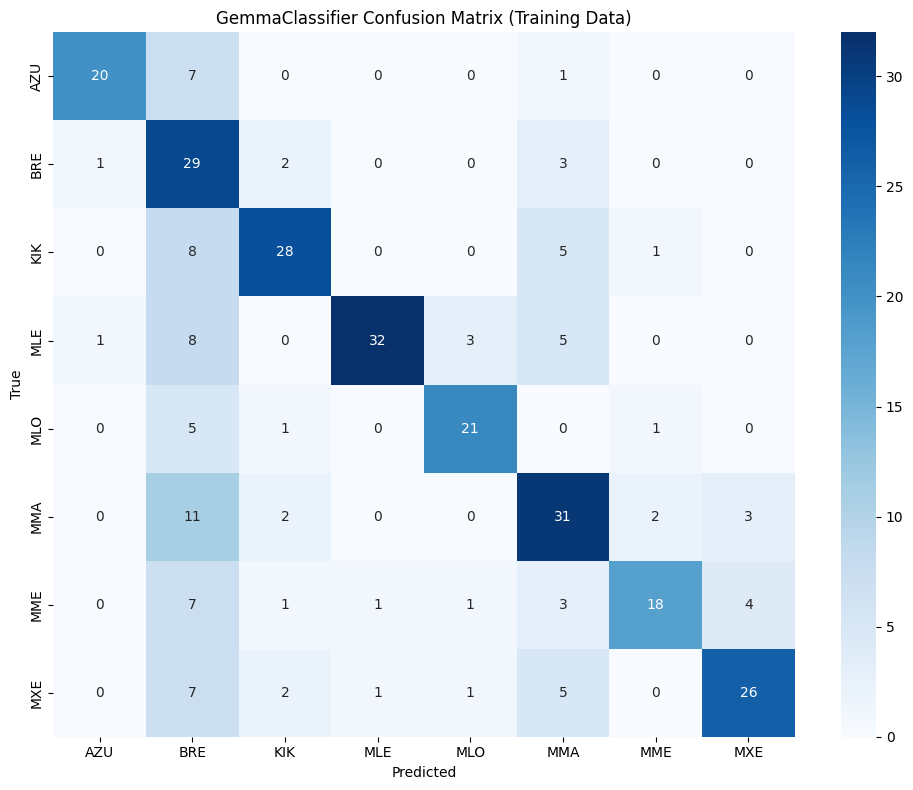

              precision    recall  f1-score   support

         AZU       0.91      0.71      0.80        28
         BRE       0.35      0.83      0.50        35
         KIK       0.78      0.67      0.72        42
         MLE       0.94      0.65      0.77        49
         MLO       0.81      0.75      0.78        28
         MMA       0.58      0.63      0.61        49
         MME       0.82      0.51      0.63        35
         MXE       0.79      0.62      0.69        42

    accuracy                           0.67       308
   macro avg       0.75      0.67      0.69       308
weighted avg       0.75      0.67      0.68       308



In [21]:
clf_model.eval()
all_true, all_pred = [], []
for s in train_data:
    prompt = EmbeddingDataset([s]).build_prompt(s['features'])
    enc = tokenizer(prompt, return_tensors="pt",
                    truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = clf_model(enc["input_ids"], enc["attention_mask"])
    all_true.append(s['label'])
    all_pred.append(LABELS[logits.argmax(-1).item()])

cm = confusion_matrix(all_true, all_pred, labels=LABELS)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS,
            yticklabels=LABELS, cmap='Blues')
plt.title("GemmaClassifier Confusion Matrix (Training Data)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()
print(classification_report(all_true, all_pred, target_names=LABELS))